# EDA 10: GEO Sample Metadata

## Purpose

`10_GEOInfo.txt` is the bridge that lets GEO expression (notebook 03) mean anything at a cell-line
level — without it, the `GSM...` sample columns in file 3 are anonymous. This notebook covers the
file's own completeness and matching structure; the full multi-hop join to the primary identity
spine was already computed in notebook 03 §5 and is not repeated here.

**Source, release, grain:** GEO sample metadata. One row per `GSM` accession, 3,267 rows.

## Questions this notebook must answer

1. What fraction of rows carry only an accession versus full descriptive metadata?
2. What fraction of `GSM` samples can be matched to a named cell line at all?
3. Of the matched samples, what disease/tissue annotation coverage exists?
4. Does the `Matching_Type` field indicate how reliable each match is?

**Interpretation rule:** a row present here with a `Cellosaurus_ID` is `measured` for identity
purposes; a row with only an accession and no further metadata cannot be attributed to a cell line
and is effectively unusable evidence, not `measured_absent` in the biological sense.

## Column dictionary

| Column | Meaning | Notes |
|---|---|---|
| `Geo_accession` | `GSM...` sample ID | matches a column header in file 3 |
| `Cellosaurus_ID` | `CVCL_...` | bridges to file 7, then file 9 |
| `Cellline` | matched cell-line name | NaN if unmatched |
| `Matching_Type` | how the match was made | reliability signal |
| `disease`, `origin` | tissue/disease annotation | only populated for a subset of rows |
| `platform_id`, `title` | GEO submission metadata | only populated for fully-annotated rows |

## 1. Basic data contract and metadata completeness

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

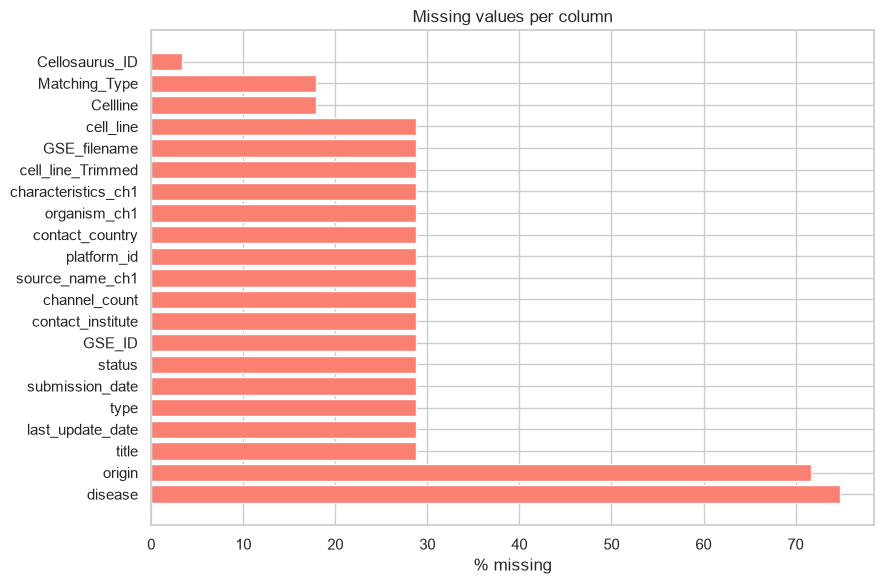

In [2]:
df = pd.read_csv(NOMENCLATURE / '10_GEOInfo.txt', sep='\t')
pct_missing = df.isnull().mean().sort_values(ascending=False) * 100
pct_missing = pct_missing[pct_missing > 0]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(pct_missing.index, pct_missing.values, color='salmon')
ax.set_xlabel('% missing'); ax.set_title('Missing values per column')
plt.tight_layout(); plt.show()

### Why this EDA check matters

A sharp two-tier missingness pattern (some rows fully annotated, others accession-only) means
"present in this table" is not itself proof of usable metadata — §2 quantifies the usable subset
directly rather than trusting row count alone.

## 2. Cell-line matching coverage

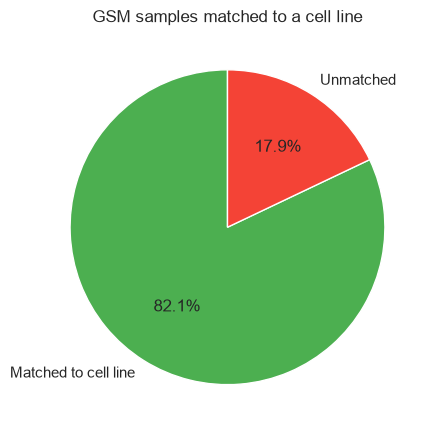

Matching_Type
Cello GEO GSM              1191
Cello Cell line Name        905
NaN                         586
Cello Cell line Synonym     528
Cello match alphanum         57
Name: count, dtype: int64


In [3]:
matched = df['Cellline'].notna().sum()
unmatched = len(df) - matched
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.pie([matched, unmatched], labels=['Matched to cell line', 'Unmatched'], autopct='%1.1f%%',
       startangle=90, colors=['#4CAF50', '#F44336'])
ax.set_title('GSM samples matched to a cell line')
plt.tight_layout(); plt.show()
print(df['Matching_Type'].value_counts(dropna=False))

### Why this EDA check matters

This is the file's core job, and its failure rate directly bounds how much of GEO expression
(notebook 03) is usable — `Matching_Type` distinguishes a confident automated match from a weaker
one, which should carry through as a confidence signal, not be treated uniformly.

## 3. Disease and tissue annotation coverage

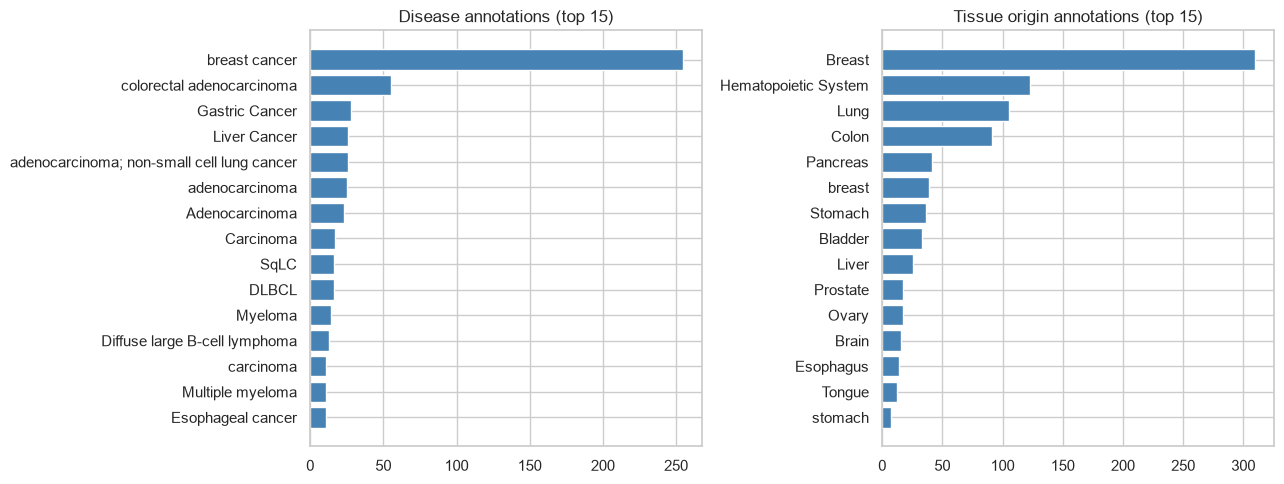

Rows with a disease annotation: 824 of 3267 (25.2%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in [(axes[0], 'disease', 'Disease annotations (top 15)'),
                         (axes[1], 'origin', 'Tissue origin annotations (top 15)')]:
    vc = df[col].value_counts().head(15)
    ax.barh(vc.index[::-1], vc.values[::-1], color='steelblue')
    ax.set_title(title)
plt.tight_layout(); plt.show()
print(f"Rows with a disease annotation: {df['disease'].notna().sum()} of {len(df)} ({df['disease'].notna().mean():.1%})")

### Why this EDA check matters

Even among matched samples, disease/tissue annotation is a further, smaller subset — any use of
this file for lineage-stratified GEO analysis (not just identity resolution) is bounded by this
narrower coverage, not the full 3,267 rows.

## Decisions carried into the next notebooks

1. **A row's presence here does not guarantee a usable cell-line match** — check `Cellline`/
   `Cellosaurus_ID` directly, and treat `Matching_Type` as a confidence signal.
2. Disease/tissue annotation coverage is narrower still than identity-match coverage — do not
   assume every identity-resolved GEO sample also carries usable biological context.
3. The full multi-hop identity path from this file's `Cellosaurus_ID` through to the primary spine
   was already established in notebook 03 §5 — reuse that computation, do not duplicate it.
4. **Limitation:** `Matching_Type` values are not individually validated here — this notebook takes
   the field at face value as a coarse reliability signal.